**The Monty Hall Problem**  
*Problem Statement:*  
Suppose you are a guest at a television game show, where Monty Hall is the host. You are presented with three doors -- two of which have a goat behind them, while one of them has a car. You want to win the car. The host asks you to choose among these doors. Let's say you choose door no. 1. Now, the host will choose a door other than 1, and will reveal what is behind it only if it is a goat. However, since the host already knows what is behind each door, he always opens the door which has a goat behind it. Let's say the host opened door no. 3. Now you are left with doors 1 and 2, and you have to make a choice-- Do you want to switch your door from 1 to 2, or stay with door no. 1? Which one would be beneficial for you?  

*The Paradox:*  
Now, most of us have an intuitive answer which says that the best choice for me is staying, because now that I am left with just two doors, the chances of me landing on a door which has a goat behind it is 50%. However, this is the incorrect approach because we fail to consider one very important fact -- the host knew exactly which door has the car behind it, and his choice to open door no.3 was not random, but deliberate.  
How does this help us?  
Well, this changes our understanding of the question completely. The choices we initially treated as independent are in fact sequential and dependent -- each choice carries information about the ones that came before it. Door no.1 is chosen blindly by the guest, a choice the host played no part in. However, door no.2 is the door the host deliberately chose not to open. This means that the host knew what is behind door no.2 and chose not to choose it. This forces us to think-- why would the host choose door no.3 instead of door no.2? Does this mean that door no.2 has the car behind it?  
And this reasoning is exactly what leads us to believe that switching might be the right choice.  

*The Solution:*  
Let's think of this problem in a different way. Let's say there are 100 doors. Only one of these doors has a car behind it and the rest of them have goats behind them. I, the guest, choose door no. 5. Now, the host opens all the doors, except door no. 48. Should I stay with my choice, or switch it? The answer now would be to switch, because the odds of door no. 5 having a car is 1/100, while that of door no. 48 is 99/100.  
The Monty Hall Problem is exactly the same, with smaller values.  
The probability of getting a car behind one of the doors is 1/3, while that of getting a goat is 2/3. This means that in case I have already chosen the door with the car behind it, the choice of staying with my decision is favourable, and the odds in favour of staying are 1/3. On the other hand, if I choose a door which has a goat behind it, switching is the only right choice and hence, the odds in favour of switching are 2/3.  
Therefore, switching is always the better option.


**What is this simulation about?**  
This Python code is a way of representing the Monty Hall Problem. We fix the number of times the game is played, and the answer returns the chances of the guest winning if they switched or stayed. You can see both the numerical and graphical outcomes of this simulation. An interesting thing to note here is as the number of trials increases (>10,000), the P(staying) comes very close to 1/3, while that of switching comes close to 2/3. This can be visually seen in the convergence graph shown towards the end of the simulation. 

**Importing python libraries to randomise the entire process and generate graphs**

In [68]:
#import libraries
import random
import matplotlib.pyplot as plt
%matplotlib inline
random.seed(42)

**Defining the Simulation Function**

In [74]:
def monty_hall():
    doors = ["car", "goat", "goat"]      #defining the doors

    random.shuffle(doors)                #since the first door will not necessarily have a car, the order of the doors needs to be shuffled
    guest = random.randint(0,2)          #the doors have indices 0,1,2; we need to choose one of those randomly, and thus, we choose an index

    host = None                          #now we need to find the door which the guest has not chosen and has a goat behind it
    for i in range(3):
        if(guest == i):
            continue
        else:                     
            if(doors[i] == "goat"):       #we find the first occurence of the door where the goat is present
                host = i
                break

    #now, we take two cases- 1)the guest stays with the originally chosen door and 2)the guest switches to the other door

    stay_result = doors[guest] == "car"  #case-1

    switch_choice = None
    for t in range(3):                    #finding out the index for the remaining last door
        if guest != t and host != t:
            switch_choice = t
            break
    switch_result = doors[switch_choice] == "car" #case-2
        
    return stay_result, switch_result              #returning the answers

**Playing the game for n number of times** 

In [75]:
stay_count = 0
switch_count = 0
stay_rates = []
switch_rates = []
n = 100000          #change this value to see the variations in the win rates of switch and stay with respect to n

for i in range(1, n+1):
    stay, switch = monty_hall()
    stay_count += stay
    switch_count += switch
    stay_rates.append(stay_count / i * 100)
    switch_rates.append(switch_count / i * 100)

**Displaying the stay and switch win rates**

In [76]:
#output of the simulation
stay_p = (stay_count / n) * 100                  #calculating the probability of staying
switch_p =  (switch_count / n) * 100             #calculating the probability of switching
print(f"The result over {n:,} simulations is:")
print(f"Stay win rate: {stay_p:.2f}%")
print(f"Switch win rate: {switch_p:.2f}%")

The result over 100,000 simulations is:
Stay win rate: 33.27%
Switch win rate: 66.73%


**Visual representation of the win rates**

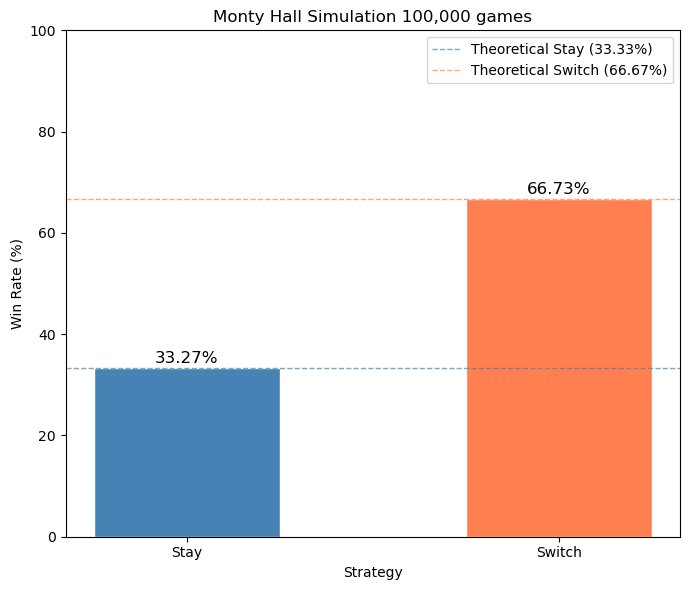

In [77]:
category = ["Stay","Switch"]
rate = [stay_p,switch_p]

fig, ax = plt.subplots(figsize = (7,6))
bars = ax.bar(category, rate, 
              color = ["steelblue", "coral"], 
              width = 0.5,
              edgecolor = "white", 
              linewidth = 1
            )

ax.axhline(y=33.33, 
           color = 'steelblue', 
           linestyle = '--', 
           linewidth = 1,
           alpha=0.7,
           label = 'Theoretical Stay (33.33%)'
           )

ax.axhline(y=66.67, 
           color = 'coral', 
           linestyle = '--', 
           linewidth = 1,
           alpha=0.7,
           label = 'Theoretical Switch (66.67%)'
           )

ax.set_ylim(0,100)
ax.set_xlabel("Strategy")
ax.set_ylabel("Win Rate (%)")
ax.set_title(f"Monty Hall Simulation {n:,} games")
              
for bar, val in zip(bars, rate):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.2f}%',
        ha = 'center', 
        fontsize = 12
        )

ax.legend(loc = 'best')

plt.tight_layout()
plt.show()
        
    

**Convergence Graph:**  
This shows that as we increase the value of n, the probabilities start approaching their actual theoretical values

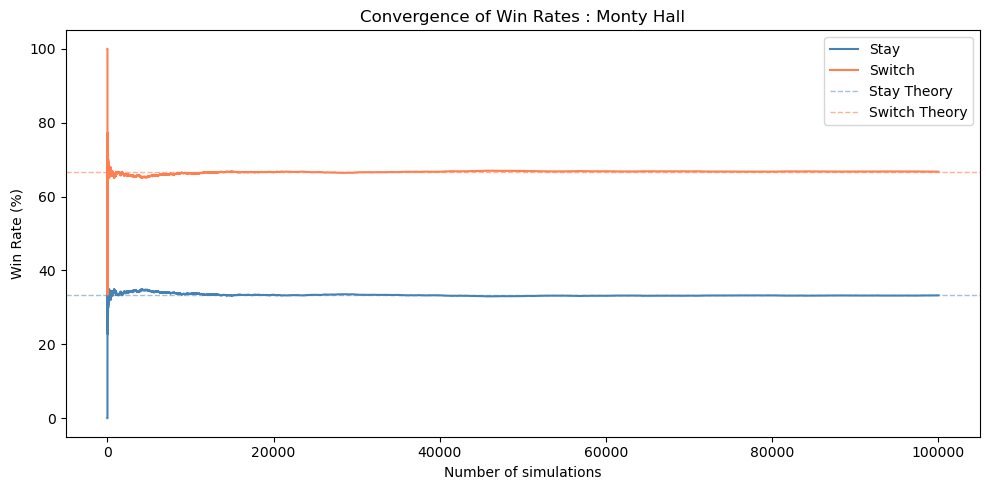

In [78]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(stay_rates, label = 'Stay', color = 'steelblue')
ax.plot(switch_rates, label = 'Switch', color = 'coral')

ax.axhline(y = 33.33, color = 'steelblue',
           linestyle = '--',
           linewidth = 1,
           alpha = 0.5,
           label = "Stay Theory"
          )
ax.axhline(y = 66.67, color = 'coral',
            linestyle='--', 
            linewidth=1,
            alpha = 0.6,
            label = "Switch Theory"
           )

ax.set_xlabel('Number of simulations')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Convergence of Win Rates : Monty Hall')

ax.legend(loc = 'best')

plt.tight_layout()
plt.show()

If you take the value of n to be small (n=100), the graph will be noisy. But as you keep on increasing the value of n, the values of switch and stay will start converging to 66.67% and 33.33%. This is the *Law of Large Numbers* in action.